In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report
)

In [27]:
data_path = "../data/heart_disease_selected.csv"
df = pd.read_csv(data_path)
df


,exang,ca,thal,thalach,oldpeak,cp,sex,target
0,-0.698344,-0.714911,-2.147955,0.018826,1.084022,1.976470,0.682656,0
1,-0.698344,-0.714911,-0.513994,1.636979,2.118926,1.005911,0.682656,0
2,-0.698344,-0.714911,-0.513994,0.980971,0.307844,0.035352,-1.464866,0
3,-0.698344,-0.714911,-0.513994,1.243374,-0.209608,0.035352,0.682656,0
4,1.431958,-0.714911,-0.513994,0.587366,-0.382092,-0.935208,-1.464866,0
...,...,...,...,...,...,...,...,...
297,1.431958,-0.714911,1.119967,-1.161988,-0.727060,-0.935208,-1.464866,-1
298,-0.698344,-0.714911,1.119967,-0.768384,0.135360,1.976470,0.682656,-1
299,-0.698344,1.274980,1.119967,-0.374779,2.032684,-0.935208,0.682656,-1
300,1.431958,0.280034,1.119967,-1.511859,0.135360,-0.935208,0.682656,-1


In [28]:
X = df.drop(columns=["target"])
y = df["target"].astype(int)

In [29]:
if set(y.unique()) <= {0, 1}:
    print("✅ Labels already binary {0,1}")
    y = y.astype(int)

elif set(y.unique()) <= {-1, 0}:
    print("⚠️ Labels are {-1,0} → converting -1 → 1")
    y = y.replace(-1, 1).astype(int)

else:
    print("⚠️ Multi-class labels detected → collapsing to binary (0 vs disease)")
    y = (y > 0).astype(int)

print("\nLabel distribution in full dataset:\n", y.value_counts())

⚠️ Labels are {-1,0} → converting -1 → 1

Label distribution in full dataset:
 target
0    164
1    138
Name: count, dtype: int64


In [30]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
print(y_train.value_counts())
print(y_test.value_counts())

target
0    131
1    110
Name: count, dtype: int64
target
0    33
1    28
Name: count, dtype: int64


In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="liblinear"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = {}


In [33]:
for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }

    print(f"\n {name} Classification Report:\n", classification_report(y_test, y_pred))


🔹 Training Logistic Regression...

 Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82        33
           1       0.79      0.79      0.79        28

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61


🔹 Training Decision Tree...

 Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.64      0.65        33
           1       0.59      0.61      0.60        28

    accuracy                           0.62        61
   macro avg       0.62      0.62      0.62        61
weighted avg       0.62      0.62      0.62        61


🔹 Training Random Forest...

 Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.79      0.78        33
           1      


Model Performance:
                      Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.803279   0.785714  0.785714  0.785714  0.890693
Decision Tree        0.622951   0.586207  0.607143  0.596491  0.621753
Random Forest        0.754098   0.740741  0.714286  0.727273  0.875000
SVM                  0.836066   0.846154  0.785714  0.814815  0.887446


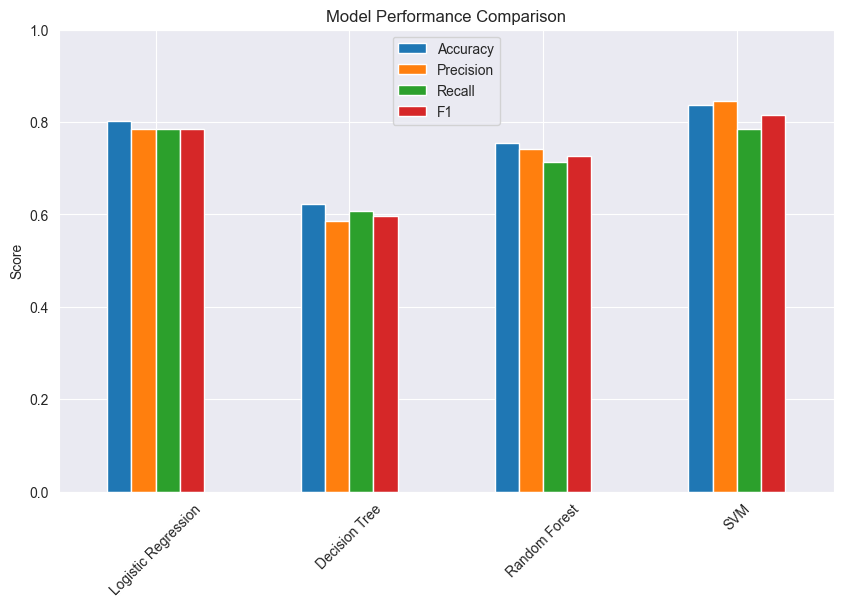

In [34]:
results_df = pd.DataFrame(results).T
print("\nModel Performance:\n", results_df)

# Bar plot of metrics
results_df[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

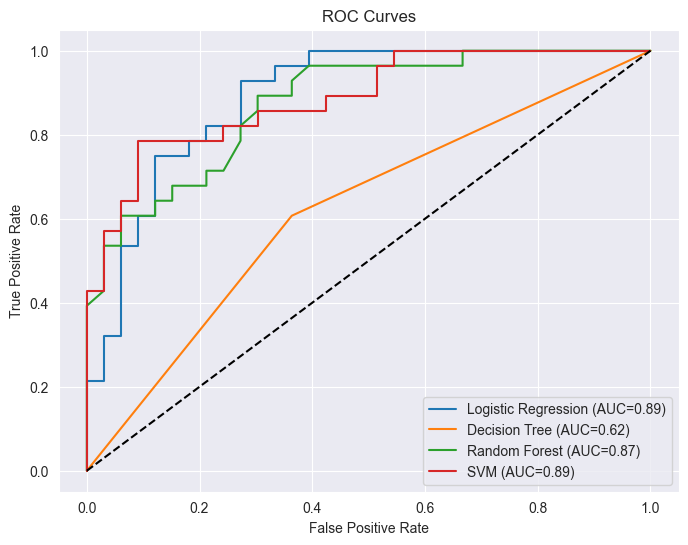

In [35]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [38]:
results_df.to_csv("../results/evaluation_metrics.csv", index=True)
